# Bean There: Q1 2026 Sales Review

**Prepared for:** the owner and store managers
**Prepared by:** Bean There analytics
**Period covered:** 1 January to 31 March 2026
**Data:** till exports for all three stores (`data/bean_there_sales.csv`)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlelocation": "left",
    "axes.titleweight": "bold",
})
BLUE, GREY = "#4C72B0", "#B8BEC6"

sales = pd.read_csv("../data/bean_there_sales.csv", parse_dates=["date"])
sales["month"] = sales["date"].dt.to_period("M")
sales["weekend"] = sales["date"].dt.dayofweek >= 5

In [2]:
monthly = sales.groupby("month").agg(revenue=("revenue", "sum"),
                                     days=("date", "nunique"))
monthly["per_day"] = monthly["revenue"] / monthly["days"]

store_share = (sales.groupby("store")["revenue"].sum()
               / sales["revenue"].sum())

units = sales.pivot_table(index="product", columns="month",
                          values="quantity", aggfunc="sum")
growth = (units.iloc[:, -1] / units.iloc[:, 0] - 1).sort_values()

store_days = (sales.groupby(["store", "date", "weekend"])["revenue"]
              .sum().reset_index())
weekend_lift = (store_days.groupby(["store", "weekend"])["revenue"]
                .mean().unstack())
weekend_lift["change"] = weekend_lift[True] / weekend_lift[False] - 1

## Summary

In [3]:
total = sales["revenue"].sum()
per_day = monthly["per_day"]
day_growth = per_day.iloc[-1] / per_day.iloc[0] - 1
uni = weekend_lift.loc["University", "change"]

Markdown(f"""
- **Revenue for the quarter was ${total:,.0f}.** Average revenue per day
  rose every month, from ${per_day.iloc[0]:,.0f} in January to
  ${per_day.iloc[-1]:,.0f} in March (**{day_growth:+.0%}**).
- **Downtown earns {store_share["Downtown"]:.0%} of revenue**, Riverside
  {store_share["Riverside"]:.0%}.
- **Cold Brew is the fastest-growing product:** units sold rose
  {growth["Cold Brew"]:.0%} from January to March.
- **University is quieter at weekends** ({uni:+.0%} per day), while the
  other two stores are busier.
- **Recommendation:** prepare Cold Brew stock and equipment for spring,
  and move University staff hours from weekends to weekdays.
""")


- **Revenue for the quarter was $160,914.** Average revenue per day
  rose every month, from $1,658 in January to
  $1,911 in March (**+15%**).
- **Downtown earns 44% of revenue**, Riverside
  25%.
- **Cold Brew is the fastest-growing product:** units sold rose
  44% from January to March.
- **University is quieter at weekends** (-13% per day), while the
  other two stores are busier.
- **Recommendation:** prepare Cold Brew stock and equipment for spring,
  and move University staff hours from weekends to weekdays.


## 1. Questions

1. Is the business growing?
2. How do the three stores compare?
3. Which products are driving growth?
4. Do the stores need different staffing on weekends?

## 2. Data and approach

The till exports record units sold and revenue for each product, store and day: 1,620 rows covering 90 days, with no missing values (see the appendix). Because February has only 28 days, monthly totals are compared **per day** rather than in total. All figures are revenue before costs.

## 3. Findings

### 3.1 Sales grew every month once February's short length is allowed for

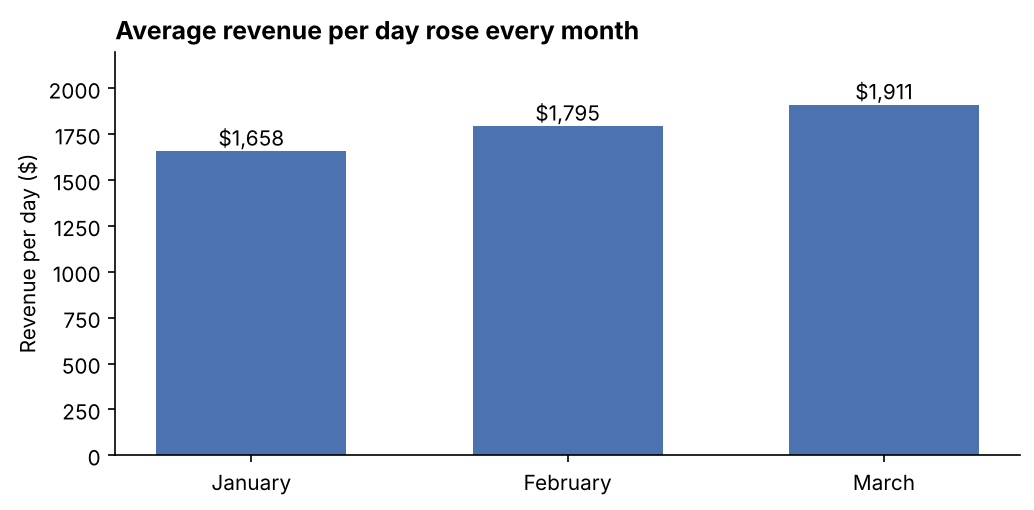

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
labels = monthly.index.strftime("%B")
ax.bar(labels, monthly["per_day"], color=BLUE, width=0.6)
for x, value in zip(labels, monthly["per_day"]):
    ax.text(x, value + 30, f"${value:,.0f}", ha="center")
ax.set_title("Average revenue per day rose every month")
ax.set_ylabel("Revenue per day ($)")
ax.set_ylim(0, 2200)
plt.tight_layout()
plt.show()

February's **total** was 2% below January's, but only because it had three fewer days. Per day, revenue grew 8% in February and another 6% in March.

### 3.2 Downtown brings in the largest share of revenue

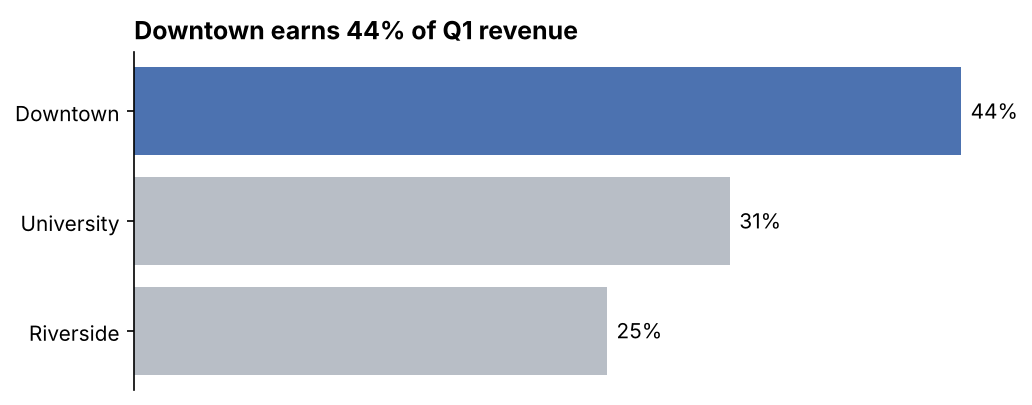

In [5]:
by_store = store_share.sort_values()
colors = [BLUE if s == "Downtown" else GREY for s in by_store.index]

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(by_store.index, by_store.values, color=colors)
for y, value in enumerate(by_store.values):
    ax.text(value + 0.005, y, f"{value:.0%}", va="center")
ax.set_title("Downtown earns 44% of Q1 revenue")
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
plt.tight_layout()
plt.show()

All three stores grew in March. Riverside is the smallest store, as expected for a quieter neighborhood shop.

### 3.3 Cold Brew is growing much faster than everything else

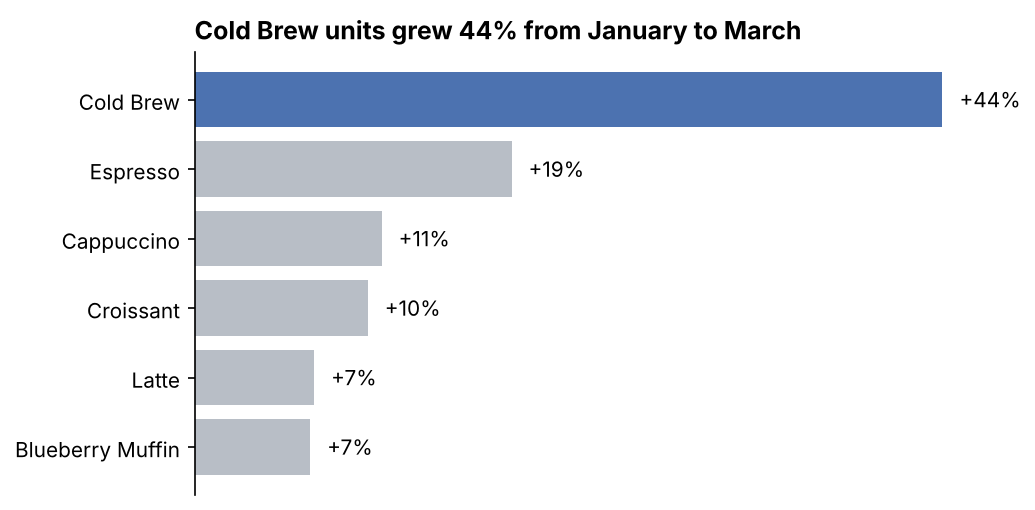

In [6]:
colors = [BLUE if p == "Cold Brew" else GREY for p in growth.index]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(growth.index, growth.values, color=colors)
for y, value in enumerate(growth.values):
    ax.text(value + 0.01, y, f"{value:+.0%}", va="center")
ax.set_title("Cold Brew units grew 44% from January to March")
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
plt.tight_layout()
plt.show()

Every product sold more in March than in January, but Cold Brew grew more than twice as fast as the next product (Espresso). In March, Cold Brew overtook Cappuccino to become the second-largest product by revenue, behind Latte. With warmer months ahead, this trend is likely to continue.

### 3.4 University is quieter at weekends; the other stores are busier

In [7]:
(weekend_lift
 .rename(columns={False: "Weekday", True: "Weekend",
                  "change": "Weekend vs weekday"})
 .style.format({"Weekday": "${:,.0f}", "Weekend": "${:,.0f}",
                "Weekend vs weekday": "{:+.0%}"}))

weekend,Weekday,Weekend,Weekend vs weekday
store,,,
Downtown,$728,$907,+25%
Riverside,$421,$508,+21%
University,$584,$508,-13%


Average revenue per day. University sits next to the campus, so it loses customers when classes stop at weekends.

## 4. Recommendations

1. **Plan for Cold Brew.** Increase Cold Brew stock and check brewing capacity before the warmer months, starting with Downtown.
2. **Rebalance University staffing.** Move staff hours from weekends to weekdays at University; add weekend cover at Downtown and Riverside.
3. **Don't react to February.** The lower February total was a calendar effect, not a slowdown.

## 5. Limitations and next steps

- Three months of data cannot separate long-term growth from seasonal patterns. Comparing with Q1 2025 would help.
- The data covers revenue only. Adding costs would show which products are most **profitable**, not just most popular.
- Next: combine these results with the loyalty-app promotion test (Chapter 14) and the revenue forecasts (Chapter 15).

## Appendix: data checks

In [8]:
pd.DataFrame({
    "rows": [len(sales)],
    "first day": [sales["date"].min().date()],
    "last day": [sales["date"].max().date()],
    "stores": [sales["store"].nunique()],
    "products": [sales["product"].nunique()],
    "missing values": [int(sales.isna().sum().sum())],
}, index=["Q1 2026"])

,rows,first day,last day,stores,products,missing values
Q1 2026,1620,2026-01-01,2026-03-31,3,6,0


---

## Chapter 16 workshop

*Every cell from here on is tagged `remove_cell`, so it does not appear in the exported report.*

### A chart before its makeover

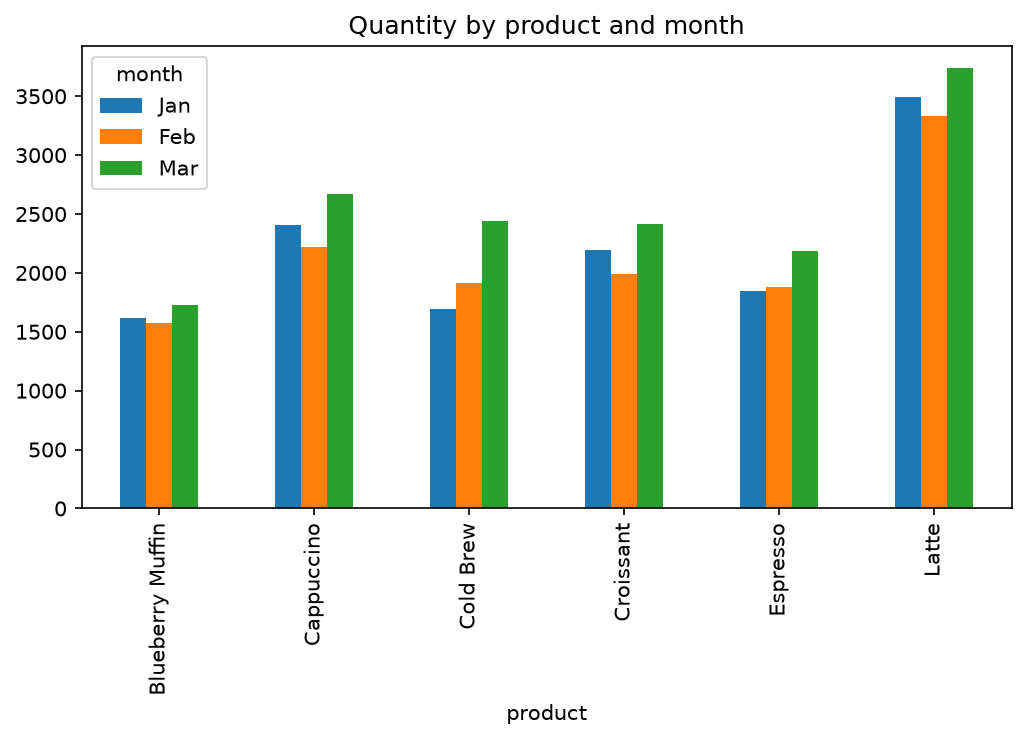

In [9]:
units.columns = units.columns.strftime("%b")
with plt.style.context("default"):
    units.plot(kind="bar", figsize=(8, 4))
    plt.title("Quantity by product and month")
    plt.show()

## Exercises

*Solutions are in Appendix D of the book.*

1. Add a finding **3.5** to the report: which store grew fastest from January to March, measured per day? Write the headline as a complete sentence and support it with one chart. *Hint:* make a store-by-month pivot table of revenue and divide it by the number of days in each month.
2. Extend the summary cell so it also reports Bean There's best day of the quarter (date and revenue). Then run **Restart and Run All** and check that the summary updates. *Hint:* `idxmax()` and the date format `{best_day:%A %d %B}`.
3. Redraw the "before" chart in the workshop section so that it tells one clear story. Decide on the message first, then design the chart.
4. Write the `jupyter nbconvert` command that runs the notebook and exports it to HTML **with no code at all**, saving it as `q1_review.html`.
5. You want the appendix in the exported report to show its table but not its code. Which tag goes on the appendix code cell, and what does its metadata look like?
6. Rewrite this finding for the owner in one or two plain sentences: "The Welch t-test for weekend vs weekday daily revenue gives p = 5e-07, with a 95% CI for the difference of 124 to 256."
7. **Think about it:** write a short "pre-flight" code cell that checks the data before the report is shared (row count, missing values, date range and anything else you think matters), printing PASS or FAIL for each check.